# Spaceship Titanic, Achieves top 12.5% on Public Leaderboard
https://www.kaggle.com/competitions/spaceship-titanic/overview

### Import Packages and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import joblib

In [2]:
from pathlib import Path
DATA_DIR = Path.cwd().parent / "Data"

train = pd.read_csv(DATA_DIR / "train-2.csv")
test = pd.read_csv(DATA_DIR / "test-2.csv")

### Early Analysis & Manipulation into Combined DS & Target 

In [3]:
pd.concat([train.drop("Transported", axis=1), test], axis=0).isna().sum()

PassengerId       0
HomePlanet      288
CryoSleep       310
Cabin           299
Destination     274
Age             270
VIP             296
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
Name            294
dtype: int64

In [4]:
pd.concat([train.drop("Transported", axis=1), test], axis=0).describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,12700.000000,12707.000000,12681.000000,12664.000000,12686.000000,12702.000000
mean,28.771969,222.897852,451.961675,174.906033,308.476904,306.789482
std,14.387261,647.596664,1584.370747,590.558690,1130.279641,1180.097223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,49.000000,77.000000,29.000000,57.000000,42.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
train["Transported"].mean()

np.float64(0.5036236051995858)

In [6]:
X_train = train.drop("Transported", axis=1)
X_train["Set"] = "Train"
test["Set"] = "Test"
X = pd.concat([X_train, test], axis=0).reset_index(drop=True)
y = train["Transported"]

### Feature Engineering, Null Handling, XDA
Not necessarily in that order

In [7]:
X.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Set
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,Train
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,Train
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,Train
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,Train
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,Train
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,Train
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,Train
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,Train
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,Train
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,Train


In [8]:
# Split PassengerId into group code and size, retype to int

X[["GroupCode", "GroupSize"]] = X["PassengerId"].str.split("_", expand=True)
X[["GroupCode", "GroupSize"]] = X[["GroupCode", "GroupSize"]].astype(int)

In [9]:
# Split cabin into deck, number, and side

X[["CabinDeck", "CabinNumber", "CabinSide"]] = X["Cabin"].str.split("/", expand=True)
X["CabinNumber"] = X["CabinNumber"].fillna(-999).astype(int)

In [10]:
# Make total spend column

ExpenditureCols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

X["TotalSpend"] = X[ExpenditureCols].sum(axis=1)

X["NoSpend"] = np.where(X["TotalSpend"]==0, 1, 0)

In [11]:
# Make total spend of group and proportion of total group spend cols 

gc_df = X.groupby("GroupCode").agg({
    "TotalSpend": "sum"
}).reset_index()
gc_dict = dict(zip(gc_df["GroupCode"], gc_df["TotalSpend"]))

X["GroupSpend"] = X["GroupCode"].map(gc_dict)
X["GroupSpendProportion"] = np.where(X["GroupSpend"]>0, X["TotalSpend"]/X["GroupSpend"], 0)

In [12]:
# Split name into forename and surname, make numer surnames in group and family group flag for single-surname groups

X[["FirstName", "SecondName"]] = X["Name"].str.split(" ", expand=True)

sn_df = X.groupby("GroupCode")["SecondName"].nunique().reset_index()
sn_dict = dict(zip(sn_df["GroupCode"], sn_df["SecondName"]))

X["SNsInGroup"] = X["GroupCode"].map(sn_dict)
X["FamilyGroupFlag"] = np.where(X["SNsInGroup"]==1, 1, 0)

In [13]:
# Show unique values for surname and then surname split by home planet. These both come out at 2400 so this means every surname has the same homeplanet. Helpful for null imputation.

nm1 = ~X["SecondName"].isna()
nm2 = ~X["HomePlanet"].isna()
null_mask = nm1 & nm2

print(X[null_mask].groupby(["SecondName"]).agg({
    "PassengerId": "count"
}).shape[0])

print(X[null_mask].groupby(["SecondName", "HomePlanet"]).agg({
    "PassengerId": "count"
}).shape[0])

2400
2400


In [14]:
# Create family size based on count of surname

fs_df = X[null_mask].groupby(["SecondName", "HomePlanet"]).agg({
    "PassengerId": "count"
}).reset_index()
fs_dict = dict(zip(fs_df["SecondName"], fs_df["PassengerId"]))

X["FamilySize"] = X["SecondName"].map(fs_dict)

In [15]:
# Create cabin region based on groups of 300 

X["CabinNumber"] = X["CabinNumber"]
X["CabinRegion1"]=(X["CabinNumber"]<300).astype(int)   # one-hot encoding
X["CabinRegion2"]=((X["CabinNumber"]>=300) & (X["CabinNumber"]<600)).astype(int)
X["CabinRegion3"]=((X["CabinNumber"]>=600) & (X["CabinNumber"]<900)).astype(int)
X["CabinRegion4"]=((X["CabinNumber"]>=900) & (X["CabinNumber"]<1200)).astype(int)
X["CabinRegion5"]=((X["CabinNumber"]>=1200) & (X["CabinNumber"]<1500)).astype(int)
X["CabinRegion6"]=((X["CabinNumber"]>=1500) & (X["CabinNumber"]<1800)).astype(int)
X["CabinRegion7"]=(X["CabinNumber"]>=1800).astype(int)

X.loc[X["CabinNumber"]==-999, ["CabinRegion1", "CabinNumber"]] = [0, np.nan]

In [16]:
orig_features = [
    "HomePlanet", "CryoSleep", "Cabin", "Destination", "Age",
    "VIP", "RoomService", "FoodCourt", "ShoppingMall",
    "Spa", "VRDeck"
]

X = X.copy()

for col in orig_features:
    X[f"{col}_Missing"] = X[col].isna().astype(int)

miss_cols = [f"{col}_Missing" for col in orig_features]

group_missing = (
    X.groupby("GroupCode")[miss_cols]
    .mean()
    .rename(columns=lambda c: c.replace("_Missing", "_GroupMissingRate"))
)

X = X.merge(group_missing, on="GroupCode", how="left")

X["IndividualMissingPct"] = X[miss_cols].mean(axis=1)
group_overall_missing = group_missing.mean(axis=1).rename("GroupMissingPct")

X = X.merge(group_overall_missing, on="GroupCode", how="left")


### Null Handling

In [17]:
# Prove all Cryosleepers have zero expenditure, and fill them as so

display(X.groupby("CryoSleep").agg({
    "RoomService": [max, min],
    "FoodCourt": [max, min],
    "ShoppingMall": [max, min],
    "Spa": [max, min],
    "VRDeck": [max, min],
}))

m1 = X["CryoSleep"]==True
m2 = X["RoomService"].isna()
m3 = X["FoodCourt"].isna()
m4 = X["ShoppingMall"].isna()
m5 = X["Spa"].isna()
m6 = X["VRDeck"].isna()

mask = m1 & (m2 | m3 | m4 | m5 | m6)

X.loc[mask, ExpenditureCols] = 0
X["TotalSpend"] = X[ExpenditureCols].sum(axis=1)

/var/folders/6c/psx92cbd57gd1gk2h4klzk_w0000gn/T/ipykernel_16685/3160627579.py:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  display(X.groupby("CryoSleep").agg({
/var/folders/6c/psx92cbd57gd1gk2h4klzk_w0000gn/T/ipykernel_16685/3160627579.py:3: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  display(X.groupby("CryoSleep").agg({
/var/folders/6c/psx92cbd57gd1gk2h4klzk_w0000gn/T/ipykernel_16685/3160627579.py:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the strin

RoomService      FoodCourt      ShoppingMall           Spa       \
                  max  min       max  min          max  min      max  min   
CryoSleep                                                                   
False         14327.0  0.0   29813.0  0.0      23492.0  0.0  22408.0  0.0   
True              0.0  0.0       0.0  0.0          0.0  0.0      0.0  0.0   

            VRDeck       
               max  min  
CryoSleep                
False      24133.0  0.0  
True           0.0  0.0

In [18]:
# Impute HomePlanet with the distinctly one HomePlanet CabinDecks

display(X.groupby(["CabinDeck", "HomePlanet"]).agg({
    "PassengerId":"count"
}))

print(f"Before HomePlanet Nulls: {X['HomePlanet'].isna().sum()}")

hp1 = X["HomePlanet"].isna()
cd1 = X["CabinDeck"].isin(["A", "B", "C"])
cd2 = X["CabinDeck"]=="G"
cd3 = X["CabinDeck"]=="T"

X.loc[hp1&(cd1|cd3), "HomePlanet"] = "Europa"
X.loc[hp1&cd2, "HomePlanet"] = "Earth"

print(f"After HomePlanet Nulls: {X['HomePlanet'].isna().sum()}")

PassengerId
CabinDeck HomePlanet             
A         Europa              346
B         Europa             1124
C         Europa             1081
D         Europa              296
          Mars                406
E         Earth               583
          Europa              197
          Mars                508
F         Earth              2426
          Mars               1713
G         Earth              3700
T         Europa               10

Before HomePlanet Nulls: 288
After HomePlanet Nulls: 160


In [19]:
# Impute HomePlanet by both Group and SecondName (HomePlanet is unifrom across these), make an educated guess on the final 10 based on modes and CabinDeck

print(f"Before HomePlanet Nulls: {X['HomePlanet'].isna().sum()}")

gc_df = X.groupby(["GroupCode", "HomePlanet"])["PassengerId"].count().reset_index()
gc_dict = dict(zip(gc_df["GroupCode"], gc_df["HomePlanet"]))
X["HomePlanetTemp1"] = X["GroupCode"].map(gc_dict)

sn_df2 = X.groupby(["SecondName", "HomePlanet"])["PassengerId"].count().reset_index()
sn_dict2 = dict(zip(sn_df2["SecondName"], sn_df2["HomePlanet"]))
X["HomePlanetTemp2"] = X["SecondName"].map(sn_dict2)

X["HomePlanetTemp"] = np.where(X["HomePlanetTemp1"].isna(), X["HomePlanetTemp2"], X["HomePlanetTemp1"])
X["HomePlanet"] = X["HomePlanetTemp"]

X = X.drop(["HomePlanetTemp1", "HomePlanetTemp2", "HomePlanetTemp"], axis=1).reset_index(drop=True)

print(f"After SecondName and Group Imputing HomePlanet Nulls: {X['HomePlanet'].isna().sum()}")

X.loc[(X['HomePlanet'].isna()) & ~(X['CabinDeck']=='D'), 'HomePlanet']='Earth'
X.loc[(X['HomePlanet'].isna()) & (X['CabinDeck']=='D'), 'HomePlanet']='Mars'

print(f"After Guessed Imputing HomePlanet Nulls: {X['HomePlanet'].isna().sum()}")

Before HomePlanet Nulls: 160
After SecondName and Group Imputing HomePlanet Nulls: 10
After Guessed Imputing HomePlanet Nulls: 0


In [20]:
# Imputing Destination to mode as no better rule

X.loc[(X['Destination'].isna()), 'Destination']='TRAPPIST-1e'

In [21]:
# Fill surname according to modal surname of group

GSN_gb=X[X['GroupSize']>1].groupby(['GroupCode','SecondName'])['SecondName'].size().unstack().fillna(0)
GSN_index=X[X['SecondName'].isna()][(X[X['SecondName'].isna()]['GroupCode']).isin(GSN_gb.index)].index

X.loc[GSN_index,'SecondName']=X.iloc[GSN_index,:]['GroupCode'].map(lambda x: GSN_gb.idxmax(axis=1)[x])

In [22]:
# Update family size

X["SecondName"].fillna("Unknown", inplace=True)
X["FamilySize"]=X["SecondName"].map(lambda x: X["SecondName"].value_counts()[x])

X.loc[X["SecondName"]=="Unknown","SecondName"]=np.nan
X.loc[X["FamilySize"]>100,"FamilySize"]=0

/var/folders/6c/psx92cbd57gd1gk2h4klzk_w0000gn/T/ipykernel_16685/1768380449.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["SecondName"].fillna("Unknown", inplace=True)


In [23]:
# Fill CabinSide

GCD_gb=X[X["GroupSize"]>1].groupby(["GroupCode","CabinDeck"])["CabinDeck"].size().unstack().fillna(0)
GCN_gb=X[X["GroupSize"]>1].groupby(["GroupCode","CabinNumber"])["CabinNumber"].size().unstack().fillna(0)
GCS_gb=X[X["GroupSize"]>1].groupby(["GroupCode","CabinSide"])["CabinSide"].size().unstack().fillna(0)

CS_bef=X["CabinSide"].isna().sum()

GCS_index=X[X["CabinSide"].isna()][(X[X["CabinSide"].isna()]["GroupCode"]).isin(GCS_gb.index)].index

X.loc[GCS_index,"CabinSide"]=X.iloc[GCS_index,:]["GroupCode"].map(lambda x: GCS_gb.idxmax(axis=1)[x])

print("#CabinSide missing values before:",CS_bef)
print("#CabinSide missing values after:",X["CabinSide"].isna().sum())

#CabinSide missing values before: 299
#CabinSide missing values after: 192


In [24]:
# Fill CabinSide

SCS_gb=X[X["GroupSize"]>1].groupby(["SecondName","CabinSide"])["CabinSide"].size().unstack().fillna(0)
SCS_gb["Ratio"]=SCS_gb["P"]/(SCS_gb["P"]+SCS_gb["S"])
CS_bef=X["CabinSide"].isna().sum()
SCS_gb.drop("Ratio", axis=1, inplace=True)
SCS_index=X[X["CabinSide"].isna()][(X[X["CabinSide"].isna()]["SecondName"]).isin(SCS_gb.index)].index
X.loc[SCS_index,"CabinSide"]=X.iloc[SCS_index,:]["SecondName"].map(lambda x: SCS_gb.idxmax(axis=1)[x])
X.drop("SecondName", axis=1, inplace=True)

X.loc[X["CabinSide"].isna(),"CabinSide"]="Z"

In [25]:
# Fill CabinDeck

CD_bef=X["CabinDeck"].isna().sum()
GCD_index=X[X["CabinDeck"].isna()][(X[X["CabinDeck"].isna()]["GroupCode"]).isin(GCD_gb.index)].index
X.loc[GCD_index,"CabinDeck"]=X.iloc[GCD_index,:]["GroupCode"].map(lambda x: GCD_gb.idxmax(axis=1)[x])

In [26]:
# Fill CabinDeck

X["Solo"] = np.where(X["GroupSize"]==1, 1, 0)

CD_bef=X["CabinDeck"].isna().sum()

na_rows_CD=X.loc[X["CabinDeck"].isna(),"CabinDeck"].index
X.loc[X["CabinDeck"].isna(),"CabinDeck"]=X.groupby(["HomePlanet","Destination","Solo"])["CabinDeck"].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CD]

Text(0.5, 1.0, 'CabinNumber vs group coloured by group')

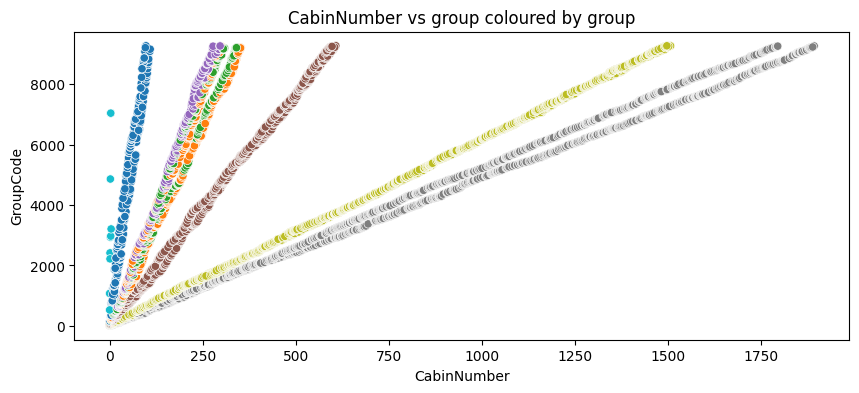

In [27]:
# Map GroupCode & CabinNumber

plt.figure(figsize=(10,4))
sns.scatterplot(x=X["CabinNumber"], y=X["GroupCode"], c=LabelEncoder().fit_transform(X.loc[~X["CabinNumber"].isna(),"CabinDeck"]), cmap="tab10")
plt.title("CabinNumber vs group coloured by group")

In [28]:
# Linear regress approximate CabinNumber

for deck in ["A", "B", "C", "D", "E", "F", "G"]:
    X_CN=X.loc[~(X["CabinNumber"].isna()) & (X["CabinDeck"]==deck),"GroupCode"]
    y_CN=X.loc[~(X["CabinNumber"].isna()) & (X["CabinDeck"]==deck),"CabinNumber"]
    X_test_CN=X.loc[(X["CabinNumber"].isna()) & (X["CabinDeck"]==deck),"GroupCode"]

    model_CN=LinearRegression()
    model_CN.fit(X_CN.values.reshape(-1, 1), y_CN)
    preds_CN=model_CN.predict(X_test_CN.values.reshape(-1, 1))
    
    X.loc[(X["CabinNumber"].isna()) & (X["CabinDeck"]==deck),"CabinNumber"]=preds_CN.astype(int)

In [29]:
# Update CabinRegion based on previous

X["CabinRegion1"]=(X["CabinNumber"]<300).astype(int)
X["CabinRegion2"]=((X["CabinNumber"]>=300) & (X["CabinNumber"]<600)).astype(int)
X["CabinRegion3"]=((X["CabinNumber"]>=600) & (X["CabinNumber"]<900)).astype(int)
X["CabinRegion4"]=((X["CabinNumber"]>=900) & (X["CabinNumber"]<1200)).astype(int)
X["CabinRegion5"]=((X["CabinNumber"]>=1200) & (X["CabinNumber"]<1500)).astype(int)
X["CabinRegion6"]=((X["CabinNumber"]>=1500) & (X["CabinNumber"]<1800)).astype(int)
X["CabinRegion7"]=(X["CabinNumber"]>=1800).astype(int)

In [30]:
# Check modal value for VIP

X["VIP"].value_counts()

VIP
False    12401
True       273
Name: count, dtype: int64

In [31]:
# Impute VIP to modal value as so imbalanced

X.loc[X["VIP"].isna(),"VIP"]=False

In [32]:
# Impute Age according to median of HomePlanet, NoSpend, Solo, and CabinDeck

na_rows_A=X.loc[X["Age"].isna(),"Age"].index
X.loc[X["Age"].isna(),"Age"]=X.groupby(["HomePlanet","NoSpend","Solo","CabinDeck"])["Age"].transform(lambda x: x.fillna(x.median()))[na_rows_A]

In [33]:
# Impute CryoSleep based on NoSpend mode (any spend imputes to no CryoSleep, no spend imputes to CryoSleep)

na_rows_CSL=X.loc[X["CryoSleep"].isna(),"CryoSleep"].index
X.loc[X["CryoSleep"].isna(),"CryoSleep"]=X.groupby(["NoSpend"])["CryoSleep"].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CSL]

/var/folders/6c/psx92cbd57gd1gk2h4klzk_w0000gn/T/ipykernel_16685/3801998714.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.loc[X["CryoSleep"].isna(),"CryoSleep"]=X.groupby(["NoSpend"])["CryoSleep"].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[na_rows_CSL]


In [34]:
# Impute spend columns based on the median by HomePlanet and Solo

for col in ExpenditureCols:
    na_rows=X.loc[X[col].isna(),col].index
    X.loc[X[col].isna(),col]=X.groupby(["HomePlanet","Solo"])[col].transform(lambda x: x.fillna(x.median()))[na_rows]

In [35]:
# Update TotalSpend and create NoSpend binary

X["TotalSpend"]=X[ExpenditureCols].sum(axis=1)
X["NoSpend"]=(X["TotalSpend"]==0).astype(int)

In [36]:
# Make group aggreagted columns

gc_min_a_df = X.groupby("GroupCode").agg({
    "Age": "min"
}).reset_index()
gc_min_a_dict = dict(zip(gc_min_a_df["GroupCode"], gc_min_a_df["Age"]))

X["GroupMinAge"] = X["GroupCode"].map(gc_min_a_dict)
X["GroupHasChild"] = (X["GroupMinAge"]<18).astype(bool)

In [37]:
# Make group aggreagted columns

gc_max_a_df = X.groupby("GroupCode").agg({
    "Age": "max"
}).reset_index()
gc_max_a_dict = dict(zip(gc_max_a_df["GroupCode"], gc_max_a_df["Age"]))

X["GroupMaxAge"] = X["GroupCode"].map(gc_max_a_dict)
X["GroupHasEldery"] = (X["GroupMaxAge"]>60).astype(bool)

In [38]:
# Make group aggreagted columns

gc_mean_cry_df = X.groupby("GroupCode").agg({
    "CryoSleep": "mean"
}).reset_index()
gc_mean_cry_dict = dict(zip(gc_mean_cry_df["GroupCode"], gc_mean_cry_df["CryoSleep"]))

X["GroupMeanCry"] = X["GroupCode"].map(gc_mean_cry_dict)

In [39]:
# Make group aggreagted columns

gc_mean_spend_df = X.groupby("GroupCode").agg({
    "TotalSpend": "mean"
}).reset_index()
gc_mean_spend_dict = dict(zip(gc_mean_spend_df["GroupCode"], gc_mean_spend_df["TotalSpend"]))

X["GroupMeanSpend"] = X["GroupCode"].map(gc_mean_spend_dict)

In [40]:
# Make group aggreagted columns

gc_mode_cd_df = X.groupby("GroupCode")["CabinDeck"].apply(lambda x: x.mode().iat[0]).reset_index()
gc_mode_cd_dict = dict(zip(gc_mode_cd_df["GroupCode"], gc_mode_cd_df["CabinDeck"]))

X["GroupModeCabinDeck"] = X["GroupCode"].map(gc_mode_cd_dict)

In [41]:
region_cols = [f"CabinRegion{i}" for i in range(1, 8)]

X["CabinRegion"] = X[region_cols].idxmax(axis=1)

In [42]:
# Make group aggreagted columns

gc_mode_cr_df = X.groupby("GroupCode")["CabinRegion"].apply(lambda x: x.mode().iat[0]).reset_index()
gc_mode_cr_dict = dict(zip(gc_mode_cr_df["GroupCode"], gc_mode_cr_df["CabinRegion"]))

X["GroupModeCabinRegion"] = X["GroupCode"].map(gc_mode_cr_dict)

In [43]:
# Make group aggreagted columns

gc_mode_dn_df = X.groupby("GroupCode")["Destination"].apply(lambda x: x.mode().iat[0]).reset_index()
gc_mode_dn_dict = dict(zip(gc_mode_dn_df["GroupCode"], gc_mode_dn_df["Destination"]))

X["GroupModeDestination"] = X["GroupCode"].map(gc_mode_dn_dict)

In [44]:
# Drop not needed variables

X = X.drop(["Name", "Cabin", "FirstName", "GroupCode"], axis=1)

In [45]:
# Check Nulls

X.isna().sum()

PassengerId             0
HomePlanet              0
CryoSleep               0
Destination             0
Age                     0
                       ..
GroupMeanSpend          0
GroupModeCabinDeck      0
CabinRegion             0
GroupModeCabinRegion    0
GroupModeDestination    0
Length: 65, dtype: int64

### Test only Nulls have been changed

In [46]:
# Test only nulls have been edited for train df

og_cols = train.columns

train_check_df = X[X["Set"]=="Train"].reset_index(drop=True)
new_cols = train_check_df.columns
train_check_df = train_check_df[[i for i in og_cols if i in train_check_df.columns]].reset_index(drop=True)

train_check_df.columns = [i + "_EDITED" for i in train_check_df.columns]

keep_cols = [i for i in og_cols if i in new_cols]
check_df = pd.concat([train[keep_cols], train_check_df], axis=1)

del train_check_df

In [47]:
# Run test for train df

for i in keep_cols:
    no_matches = (check_df[i] != check_df[i+"_EDITED"]).sum()
    nulls = train[i].isna().sum()
    if no_matches == nulls:
        outcome = "Only Nulls Edited, Test Passed!"
    else:
        outcome = "Test Failed, Please Change"
    print(f"For Variable: {i}, Original Nulls: {nulls}, No Matches: {no_matches}. Outcome: {outcome}")

del check_df

For Variable: PassengerId, Original Nulls: 0, No Matches: 0. Outcome: Only Nulls Edited, Test Passed!
For Variable: HomePlanet, Original Nulls: 201, No Matches: 201. Outcome: Only Nulls Edited, Test Passed!
For Variable: CryoSleep, Original Nulls: 217, No Matches: 217. Outcome: Only Nulls Edited, Test Passed!
For Variable: Destination, Original Nulls: 182, No Matches: 182. Outcome: Only Nulls Edited, Test Passed!
For Variable: Age, Original Nulls: 179, No Matches: 179. Outcome: Only Nulls Edited, Test Passed!
For Variable: VIP, Original Nulls: 203, No Matches: 203. Outcome: Only Nulls Edited, Test Passed!
For Variable: RoomService, Original Nulls: 181, No Matches: 181. Outcome: Only Nulls Edited, Test Passed!
For Variable: FoodCourt, Original Nulls: 183, No Matches: 183. Outcome: Only Nulls Edited, Test Passed!
For Variable: ShoppingMall, Original Nulls: 208, No Matches: 208. Outcome: Only Nulls Edited, Test Passed!
For Variable: Spa, Original Nulls: 183, No Matches: 183. Outcome: Only

In [48]:
# Test only nulls have been edited for test df

og_cols = test.columns

test_check_df = X[X["Set"]=="Test"].reset_index(drop=True)
new_cols = test_check_df.columns
test_check_df = test_check_df[[i for i in og_cols if i in test_check_df.columns]].reset_index(drop=True)

test_check_df.columns = [i + "_EDITED" for i in test_check_df.columns]

keep_cols = [i for i in og_cols if i in new_cols]
check_df = pd.concat([test[keep_cols], test_check_df], axis=1)

del test_check_df

In [49]:
# Run test for test df

for i in keep_cols:
    no_matches = (check_df[i] != check_df[i+"_EDITED"]).sum()
    nulls = test[i].isna().sum()
    if no_matches == nulls:
        outcome = "Only Nulls Edited, Test Passed!"
    else:
        outcome = "Test Failed, Please Change"
    print(f"For Variable: {i}, Original Nulls: {nulls}, No Matches: {no_matches}. Outcome: {outcome}")

For Variable: PassengerId, Original Nulls: 0, No Matches: 0. Outcome: Only Nulls Edited, Test Passed!
For Variable: HomePlanet, Original Nulls: 87, No Matches: 87. Outcome: Only Nulls Edited, Test Passed!
For Variable: CryoSleep, Original Nulls: 93, No Matches: 93. Outcome: Only Nulls Edited, Test Passed!
For Variable: Destination, Original Nulls: 92, No Matches: 92. Outcome: Only Nulls Edited, Test Passed!
For Variable: Age, Original Nulls: 91, No Matches: 91. Outcome: Only Nulls Edited, Test Passed!
For Variable: VIP, Original Nulls: 93, No Matches: 93. Outcome: Only Nulls Edited, Test Passed!
For Variable: RoomService, Original Nulls: 82, No Matches: 82. Outcome: Only Nulls Edited, Test Passed!
For Variable: FoodCourt, Original Nulls: 106, No Matches: 106. Outcome: Only Nulls Edited, Test Passed!
For Variable: ShoppingMall, Original Nulls: 98, No Matches: 98. Outcome: Only Nulls Edited, Test Passed!
For Variable: Spa, Original Nulls: 101, No Matches: 101. Outcome: Only Nulls Edited,

### Data Preparation for Modelling

In [50]:
# Define one-hot encoding targets which are categorical variables to be 0/1 encoded. Define dropping targets which are useless to us

OH_targs = ["HomePlanet", "CryoSleep", "Destination", "VIP", "CabinDeck", "CabinSide", "CabinRegion", "GroupModeCabinDeck", "GroupModeDestination", "GroupModeCabinRegion"]
drop_targs = ["CabinNumber", "Set"]

dummies = pd.get_dummies(X[OH_targs], dtype=int) 
X = pd.concat([X, dummies], axis=1) 

In [51]:
# Define sets for training & testing models

X_train = X[X["Set"]=="Train"].reset_index(drop=True)
X_train = X_train.drop(drop_targs, axis=1).reset_index(drop=True)
X_test = X[X["Set"]=="Test"].reset_index(drop=True)
X_test = X_test.drop(drop_targs, axis=1).reset_index(drop=True)
y_train = train["Transported"].astype(int)

In [52]:
# Define columns to use for linear models (no linear dependencies among these)

linear_cols = ["Age", "TotalSpend", "NoSpend", "GroupSpend", "GroupSpendProportion", "GroupSize", "SNsInGroup"
               , "FamilyGroupFlag", "FamilySize" ,"CabinRegion1", "CabinRegion2", "CabinRegion3", "CabinRegion4", "CabinRegion5"
               , "CabinRegion6", "Solo", "HomePlanet_Earth", "HomePlanet_Europa", "CryoSleep_True", "Destination_TRAPPIST-1e"
               , "Destination_PSO J318.5-22", "VIP_True", "CabinDeck_B", "CabinDeck_C", "CabinDeck_D", "CabinDeck_E"
               , "CabinDeck_F", "CabinDeck_G", "CabinDeck_T", "CabinSide_S", "CabinSide_Z"]

In [53]:
# Define columns to use for tre based models (tree models aren't affected by linear dependency)

tree_cols = [i for i in X_train.columns if "PassengerId" not in i and i not in OH_targs and "CabinRegion_CabinRegion" not in i]

In [54]:
tree_cols

['Age',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'GroupSize',
 'TotalSpend',
 'NoSpend',
 'GroupSpend',
 'GroupSpendProportion',
 'SNsInGroup',
 'FamilyGroupFlag',
 'FamilySize',
 'CabinRegion1',
 'CabinRegion2',
 'CabinRegion3',
 'CabinRegion4',
 'CabinRegion5',
 'CabinRegion6',
 'CabinRegion7',
 'HomePlanet_Missing',
 'CryoSleep_Missing',
 'Cabin_Missing',
 'Destination_Missing',
 'Age_Missing',
 'VIP_Missing',
 'RoomService_Missing',
 'FoodCourt_Missing',
 'ShoppingMall_Missing',
 'Spa_Missing',
 'VRDeck_Missing',
 'HomePlanet_GroupMissingRate',
 'CryoSleep_GroupMissingRate',
 'Cabin_GroupMissingRate',
 'Destination_GroupMissingRate',
 'Age_GroupMissingRate',
 'VIP_GroupMissingRate',
 'RoomService_GroupMissingRate',
 'FoodCourt_GroupMissingRate',
 'ShoppingMall_GroupMissingRate',
 'Spa_GroupMissingRate',
 'VRDeck_GroupMissingRate',
 'IndividualMissingPct',
 'GroupMissingPct',
 'Solo',
 'GroupMinAge',
 'GroupHasChild',
 'GroupMaxAge',
 'GroupHasEldery',
 'Gr

In [55]:
# Define columns to go into catboost (so no onehotting)

cb_cols = [i for i in tree_cols if "_" not in i and "CabinRegion" not in i] + OH_targs

In [57]:
cb_cols

['Age',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'GroupSize',
 'TotalSpend',
 'NoSpend',
 'GroupSpend',
 'GroupSpendProportion',
 'SNsInGroup',
 'FamilyGroupFlag',
 'FamilySize',
 'IndividualMissingPct',
 'GroupMissingPct',
 'Solo',
 'GroupMinAge',
 'GroupHasChild',
 'GroupMaxAge',
 'GroupHasEldery',
 'GroupMeanCry',
 'GroupMeanSpend',
 'HomePlanet',
 'CryoSleep',
 'Destination',
 'VIP',
 'CabinDeck',
 'CabinSide',
 'CabinRegion',
 'GroupModeCabinDeck',
 'GroupModeDestination',
 'GroupModeCabinRegion']

In [58]:
# Define train and test for linear and tree-based models

X_train_lin = X_train[linear_cols].reset_index(drop=True)
X_train_tree = X_train[tree_cols].reset_index(drop=True)
X_train_cb = X_train[cb_cols].reset_index(drop=True)
X_test_lin = X_test[linear_cols].reset_index(drop=True)
X_test_tree = X_test[tree_cols].reset_index(drop=True)
X_test_cb = X_test[cb_cols].reset_index(drop=True)

In [59]:
# Split a 20% holdout away from the normal for tree sets. use the same split for linear sets so performance is directly comparable across the two schools of models

X_tree_fit, X_tree_rep, y_fit, y_rep = train_test_split(X_train_tree, y_train, test_size=0.2, stratify=y_train ,random_state=99)

X_lin_fit = X_train_lin.loc[X_tree_fit.index]
X_lin_rep = X_train_lin.loc[X_tree_rep.index]

X_cb_fit = X_train_cb.loc[X_tree_fit.index]
X_cb_rep = X_train_cb.loc[X_tree_rep.index]

### Fit Tree Models
Fit CatBoost and produce preds

In [60]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=100,
    multivariate=True,
    seed=99
)

def objective(trial):

    # CatBoost hyperparameters to tune
    n_estimators = trial.suggest_int("n_estimators", 500, 2500)          # iterations
    depth = trial.suggest_int("depth", 4, 10)                          # tree depth
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)             # sampling rate
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True)
    random_strength = trial.suggest_float("random_strength", 1e-3, 5.0, log=True)
    border_count = trial.suggest_int("border_count", 32, 255)          # number of splits per feature

    model = cb.CatBoostClassifier(
        iterations=n_estimators,
        depth=depth,
        learning_rate=learning_rate,
        subsample=subsample,
        l2_leaf_reg=l2_leaf_reg,
        random_strength=random_strength,
        border_count=border_count,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=99,
        verbose=False,
        thread_count=-1,
        cat_features=OH_targs
    )

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=99)
    scores = cross_val_score(model, X_cb_fit, y_fit, cv=cv, scoring="accuracy")
    return scores.mean()

/opt/homebrew/Caskroom/miniforge/base/envs/base_env_py311/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(


In [62]:
run_tune = False

if run_tune:
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler
    )
    study.optimize(objective, n_trials=500)

    print("\nBest score:", study.best_value)
    print("\nBest params:", study.best_params)

In [61]:
# Best catboost params don't touch

best_params = {'n_estimators': 370, 'depth': 5, 'learning_rate': 0.06324086038679944, 'subsample': 0.9613187612447764, 'l2_leaf_reg': 0.5499505935179492, 'random_strength': 0.2606856218855909, 'border_count': 182}

best_cb = cb.CatBoostClassifier(
    random_state=99,
    **best_params
)

best_cb.fit(X_train_cb, y_train, cat_features=OH_targs)

0:	learn: 0.6630551	total: 64.1ms	remaining: 23.7s
1:	learn: 0.6379942	total: 71ms	remaining: 13.1s
2:	learn: 0.6166723	total: 78ms	remaining: 9.54s
3:	learn: 0.5977747	total: 85.8ms	remaining: 7.85s
4:	learn: 0.5821719	total: 92.3ms	remaining: 6.73s
5:	learn: 0.5672187	total: 98.7ms	remaining: 5.99s
6:	learn: 0.5540767	total: 106ms	remaining: 5.52s
7:	learn: 0.5403376	total: 114ms	remaining: 5.17s
8:	learn: 0.5315732	total: 123ms	remaining: 4.93s
9:	learn: 0.5233016	total: 130ms	remaining: 4.69s
10:	learn: 0.5135644	total: 137ms	remaining: 4.46s
11:	learn: 0.5056010	total: 145ms	remaining: 4.32s
12:	learn: 0.4996298	total: 154ms	remaining: 4.23s
13:	learn: 0.4948660	total: 163ms	remaining: 4.14s
14:	learn: 0.4890129	total: 171ms	remaining: 4.05s
15:	learn: 0.4848511	total: 178ms	remaining: 3.93s
16:	learn: 0.4806624	total: 183ms	remaining: 3.8s
17:	learn: 0.4747268	total: 189ms	remaining: 3.69s
18:	learn: 0.4716337	total: 196ms	remaining: 3.61s
19:	learn: 0.4679662	total: 203ms	remain

In [63]:
p = best_cb.predict(X_test_cb)

sub = pd.concat([pd.Series(test["PassengerId"]).reset_index(drop=True), pd.Series(p).astype(bool)], axis=1)
sub.columns = ["PassengerId", "Transported"]

sub.to_csv(DATA_DIR / "Final_CatBoost.csv", index=False)